## Mount Google Drive

In [43]:
from google.colab import drive
drive.mount('/content/drive',force_remount=True)

Mounted at /content/drive


## Move to Project Directory

In [45]:
import os

PROJECT_DIR = "/content/drive/MyDrive/rocket_telemetry_project"

os.chdir(PROJECT_DIR)
print("Current directory:", os.getcwd())

Current directory: /content/drive/MyDrive/rocket_telemetry_project


## Imports

In [46]:
import numpy as np
import pandas as pd
import json
import joblib
import matplotlib.pyplot as plt
from datetime import datetime

from tensorflow.keras.models import load_model

## Configuration

In [47]:
channel_id = "P-1"
window_size = 25

DATA_DIR = "data"
MODEL_DIR = "models"
RESULT_DIR = "results"

os.makedirs(f"{RESULT_DIR}/plots", exist_ok=True)
os.makedirs(f"{RESULT_DIR}/metrics", exist_ok=True)

## Load Data From Previous Pipeline

In [48]:
import os

print(os.getcwd())

/content/drive/MyDrive/rocket_telemetry_project


In [49]:
os.listdir("data")

['test', 'train', 'labeled_anomalies.csv', 'processed', 'sequences']

In [50]:
os.listdir("data/sequences")

['P-1_train_seq.npy', 'P-1_test_seq.npy', 'P-1_val_seq.npy']

In [51]:
X_train_seq = np.load(f"data/sequences/{channel_id}_train_seq.npy")
X_test_seq = np.load(f"data/sequences/{channel_id}_test_seq.npy")

print("Train sequences:", X_train_seq.shape)
print("Test sequences:", X_test_seq.shape)

Train sequences: (2547, 41, 96)
Test sequences: (8464, 41, 96)


## Load Trained Model

In [52]:
model_path = f"{MODEL_DIR}/lstm_ae_{channel_id}.h5"

if not os.path.exists(model_path):
    print(f"Error: Model file '{model_path}' not found in '{MODEL_DIR}'.")
else:
    try:
        model = load_model(model_path, compile=False)
        print("Model loaded successfully without original compilation configuration.")
    except Exception as e:
        print(f"An error occurred while loading the model: {e}")

Model loaded successfully without original compilation configuration.


## compute_reconstruction_errors

In [53]:
def compute_reconstruction_errors(model, X_seq):

    preds = model.predict(X_seq, verbose=0)

    errors = np.mean((X_seq - preds) ** 2, axis=(1,2))

    assert not np.isnan(errors).any(), "NaN detected in reconstruction errors"

    print("Computed reconstruction errors:", errors.shape)

    return errors

## percentile threshold

In [54]:
def threshold_percentile(train_errors, percentile=99):

    threshold = np.percentile(train_errors, percentile)

    print(f"Percentile Threshold ({percentile}%): {threshold:.6f}")

    return threshold

## dynamic threshold

In [55]:
def threshold_dynamic(train_errors, z=3.0, span=10):

    smoothed = pd.Series(train_errors).ewm(span=span).mean().values

    mean = smoothed.mean()
    std = smoothed.std()

    threshold = mean + z * std

    print("Dynamic Threshold Method")
    print("Mean:", mean)
    print("Std:", std)
    print("Threshold:", threshold)

    return threshold, smoothed

## detect anomalies

In [56]:
def detect_anomalies(test_errors, threshold):

    y_pred = (test_errors > threshold).astype(int)

    flagged = y_pred.sum()
    percent = flagged / len(test_errors) * 100

    print("Flagged anomalies:", flagged)
    print("Percentage:", percent)

    return y_pred

## align window labels

In [57]:
def align_window_labels(intervals, n_test_timesteps, window_size):

    labels = np.zeros(n_test_timesteps)

    for start, end in intervals:
        labels[start:end] = 1

    window_labels = []

    for i in range(n_test_timesteps - window_size):
        window = labels[i:i+window_size]

        if np.any(window == 1):
            window_labels.append(1)
        else:
            window_labels.append(0)

    window_labels = np.array(window_labels)

    print("Aligned labels:", window_labels.shape)

    assert len(window_labels) == len(test_errors)

    return window_labels

## save threshold config

In [58]:
def save_threshold_config(channel_id, threshold, method, params):

    config = {
        "channel_id": channel_id,
        "threshold": float(threshold),
        "method": method,
        "params": params,
        "timestamp": datetime.now().isoformat()
    }

    path = f"{RESULT_DIR}/metrics/{channel_id}_threshold.json"

    with open(path, "w") as f:
        json.dump(config, f, indent=4)

    print("Threshold config saved:", path)

## Compute Reconstruction Errors

In [59]:
def compute_reconstruction_errors(model, X_seq, batch_size=32):

    import numpy as np

    n = X_seq.shape[0]
    errors = []

    for i in range(0, n, batch_size):

        batch = X_seq[i:i+batch_size]

        # add missing window dimension
        if len(batch.shape) == 3:
            batch = np.expand_dims(batch, axis=1)

        preds = model.predict(batch, verbose=0)

        batch_error = np.mean((batch - preds) ** 2, axis=(1,2,3))

        errors.extend(batch_error)

    errors = np.array(errors)

    assert not np.isnan(errors).any(), "NaN detected in reconstruction errors"

    print("Computed reconstruction errors:", errors.shape)

    return errors

In [60]:
import os
os.listdir("models")

['scaler_P-1.pkl',
 'scaler_P1.pkl',
 'architecture_P1.json',
 'architecture_P-1.json',
 'lstm_ae_P-1.h5']

In [61]:
channel_id = "P-1"
MODEL_DIR = "models"

from tensorflow.keras.models import load_model
import os

model_path = f"{MODEL_DIR}/lstm_ae_{channel_id}.h5"

if not os.path.exists(model_path):
    print(f"Error: Model file '{model_path}' not found in '{MODEL_DIR}'.")
else:
    model = load_model(model_path, compile=False)
    print("Model loaded successfully")

Model loaded successfully


In [62]:
train_errors = compute_reconstruction_errors(model, X_train_seq)

test_errors = compute_reconstruction_errors(model, X_test_seq)

Computed reconstruction errors: (2547,)
Computed reconstruction errors: (8464,)


## Apply Both Threshold Methods

In [63]:
percentile_threshold = threshold_percentile(train_errors, 99)

dynamic_threshold, smoothed = threshold_dynamic(train_errors, z=3.0, span=10)

Percentile Threshold (99%): 0.013256
Dynamic Threshold Method
Mean: 0.005502719322961963
Std: 0.0032998243360344757
Threshold: 0.015402192331065389


## Compare Methods

In [65]:
print("\n--- Percentile Method ---")
y_pred_percentile = detect_anomalies(test_errors, percentile_threshold)

print("\n--- Dynamic Method ---")
y_pred_dynamic = detect_anomalies(test_errors, dynamic_threshold)



--- Percentile Method ---
Flagged anomalies: 760
Percentage: 8.979206049149338

--- Dynamic Method ---
Flagged anomalies: 383
Percentage: 4.525047258979206


## Save Final Threshold

In [66]:
def save_threshold_config(channel_id, threshold, method, params):

    import json
    from datetime import datetime
    import os

    os.makedirs("results/metrics", exist_ok=True)

    config = {
        "channel_id": channel_id,
        "threshold": float(threshold),
        "method": method,
        "params": params,
        "timestamp": datetime.now().isoformat()
    }

    path = f"results/metrics/{channel_id}_threshold.json"

    with open(path, "w") as f:
        json.dump(config, f, indent=4)

    print("Threshold config saved:", path)

## Error Distribution Plot

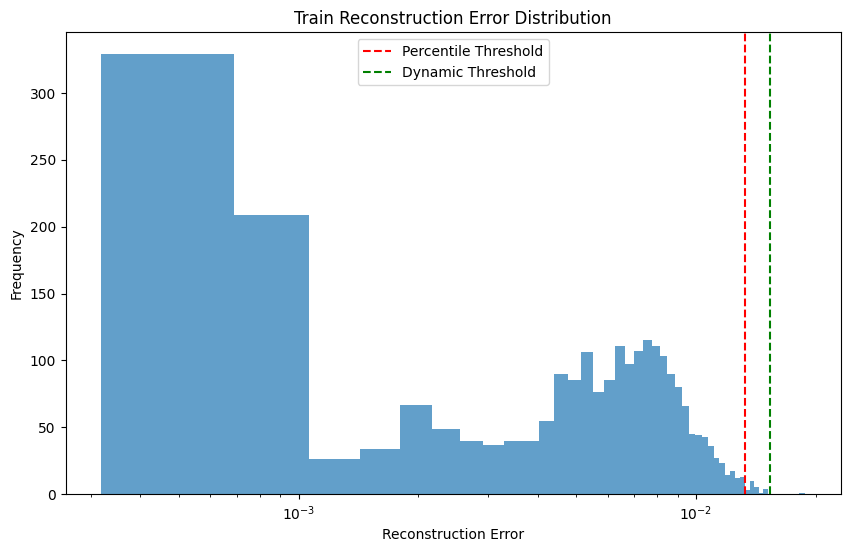

In [67]:
plt.figure(figsize=(10,6))

plt.hist(train_errors, bins=50, alpha=0.7)

plt.axvline(percentile_threshold,
            color='red',
            linestyle='--',
            label='Percentile Threshold')

plt.axvline(dynamic_threshold,
            color='green',
            linestyle='--',
            label='Dynamic Threshold')

plt.xlabel("Reconstruction Error")
plt.ylabel("Frequency")
plt.title("Train Reconstruction Error Distribution")

plt.legend()

plt.xscale("log")

plt.savefig(
    f"{RESULT_DIR}/plots/{channel_id}_error_dist.png",
    dpi=150
)

plt.show()